# Chest X-Ray Medical Diagnosis with Deep Learning

<img src="images/xray-header-image.png" style="padding-top: 50px;width: 87%;left: 0px;margin-left: 0px;margin-right: 0px;">


In this project, we will explore medical image diagnosis by building a state-of-the-art chest X-ray classifier using Keras.

The notebook will walk through some of the steps of building and evaluating this deep learning classifier model. In particular:

- Pre-process and prepare a real-world X-ray dataset.

- Use transfer learning to retrain a ['DenseNet'](https://pytorch.org/hub/pytorch_vision_densenet/) model for X-ray image classification.

- Learn a technique to handle class imbalance()

- Measure diagnostic performance by computing the [AUC (Area Under the Curve) for the ROC (Receiver Operating Characteristic) curve](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc).

- Visualize model activity using [GradCAMs](https://arxiv.org/pdf/2307.10506).

## 1. Import Packages and Functions


- **Data Handling**: [`numpy`](https://numpy.org/) and [`pandas`](https://pandas.pydata.org/) is what we'll use to manipulate our data

- **Visualization**: [`matplotlib.pyplot`](https://matplotlib.org/) and [`seaborn`](https://seaborn.pydata.org/) will be used to produce plots for visualization

- **Deep Learning**: [`keras`](https://pypi.org/project/keras/) specically: 
  - `DenseNet 121`
  - `ImageDataGenerator`
  - `Model`
  - `Dense`
  - `GlobalAveragePooling2D`

- `util` will provide the locally defined utility functions that have been provided for this assignment




In [1]:
%pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 3.7 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 3.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.4 MB/s  0:00:02m0:00:0100:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 2.0 MB/s  0:03:11m0:00:0100:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 3.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 3.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 2.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 3.0 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━

In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import util
import importlib
importlib.reload(util)
from util import load_data, preprocess_data, plot_history, plot_confusion_matrix, plot_roc_curve, plot_pr_curve


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import backend as K
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping




import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
print('libs & f(x) are imported')


libs & f(x) are imported


## 2. Load the Datasets

<img src="/home/mukhtarfeth32/AI for Medicine Projects/AI for Medical Diagnosis/Chest X-Ray Medical Diagnosis with DL (1)/images/Samples from the NIH chest X-ray dataset.png">

We will be using a <u>subset</u> of the [NIH ChestX-ray8 dataset](https://nihcc.app.box.com/v/ChestXray-NIHCC) provided by the [DeepLearning.AI institue](https://www.deeplearning.ai/the-batch/human-level-x-ray-diagnosis/)  

  - The [subset](/AI for Medicine Projects/AI for Medical Diagnosis/Chest X-Ray Medical Diagnosis with DL (1)/data/nih/images-small) is approximately **~1,000** images. 
  - The subset has been annotated by consensus among four different radiologists for 5 of  our 14 pathologies:
    - `Consolidation`
    - `Edema`
    - `Effusion`
    - `Cardiomegaly`
    - `Atelectasis`
  
  - [DeepLearning.AI](https://www.deeplearning.ai/the-batch/human-level-x-ray-diagnosis/) process that entire dataset and generate the subset, then split the data into: 
    - **875** images for training
    - **109** images for validation
    - **420** images for testing

You can explore and download the entire dataset for free [here](https://nihcc.app.box.com/v/ChestXray-NIHCC). 


<a name='2-1'></a>
### 2.1 Loading the Data
Let's open these files using the [pandas](https://pandas.pydata.org/) library

In [5]:
train_df, valid_df, test_df = load_data()
train_df.head(10)


,Image,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,PatientId,Pleural_Thickening,Pneumonia,Pneumothorax
0,00008270_015.png,0,0,0,0,0,0,0,0,0,0,0,8270,0,0,0
1,00029855_001.png,1,0,0,0,1,0,0,0,1,0,0,29855,0,0,0
2,00001297_000.png,0,0,0,0,0,0,0,0,0,0,0,1297,1,0,0
3,00012359_002.png,0,0,0,0,0,0,0,0,0,0,0,12359,0,0,0
4,00017951_001.png,0,0,0,0,0,0,0,0,1,0,0,17951,0,0,0
5,00001232_002.png,1,1,0,0,1,0,0,0,1,0,0,1232,0,0,0
6,00017135_000.png,0,0,0,0,0,0,0,0,0,0,0,17135,0,0,0
7,00027235_000.png,0,0,0,0,0,0,0,0,0,0,0,27235,0,0,0
8,00014197_007.png,0,0,0,0,0,0,0,0,0,0,0,14197,0,0,0
9,00011584_002.png,0,0,0,0,0,0,0,0,0,0,0,11584,0,0,0


In [6]:
labels = ['Cardiomegaly', 
          'Emphysema', 
          'Effusion', 
          'Hernia', 
          'Infiltration', 
          'Mass', 
          'Nodule', 
          'Atelectasis',
          'Pneumothorax',
          'Pleural_Thickening', 
          'Pneumonia', 
          'Fibrosis', 
          'Edema', 
          'Consolidation']


### 2.2 Checking For Data Leakage
Since the dataset contains multiple images for each patient. Therefore, when splitting the dataset into(train/validation/test) sets, we have ensured that the split is done on the patient level and that there is no data "leakage" between the sets.

In [7]:
def check_leakage(df1, df2, patient_col='PatientId'):
    """Check if there are common patients between two datasets."""
    overlap = set(df1[patient_col]) & set(df2[patient_col])
    return len(overlap) > 0, len(overlap)

# Check for leakage
train_valid_leak, n1 = check_leakage(train_df, valid_df)
train_test_leak, n2 = check_leakage(train_df, test_df)
valid_test_leak, n3 = check_leakage(valid_df, test_df)

print(f"Train-Valid leakage: {train_valid_leak} ({n1} patients)")
print(f"Train-Test leakage: {train_test_leak} ({n2} patients)")
print(f"Valid-Test leakage: {valid_test_leak} ({n3} patients)")


Train-Valid leakage: True (197 patients)
Train-Test leakage: False (0 patients)
Valid-Test leakage: False (0 patients)


## 3. Data Preparation 

<a name='2-3'></a>
### 3.1 Build an Image Generator for the training set

- We will be using [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator#used-in-the-notebooks) to standardize images in the training set (setting the mean to $0$ and the standard deviation to $1$)

- The `train_generator` would convert the single channel X-Ray image to $3$ channel image.

- The `train_generator` would change the image size to (target_width = 320px, target_length = 320px)

In [8]:
# Check current directory
print(f"Current directory: {os.getcwd()}")

# Set IMAGE_DIR
IMAGE_DIR = "data/nih/images-small/"

# Verify the path exists
if os.path.exists(IMAGE_DIR):
    print(f"✓ Image directory found: {IMAGE_DIR}")
    print(f"✓ Number of images: {len(os.listdir(IMAGE_DIR))}")
else:
    print(f"✗ Image directory NOT found: {IMAGE_DIR}")
    print(f"  Absolute path would be: {os.path.abspath(IMAGE_DIR)}")


Current directory: /home/mukhtarfeth32/AI for Medicine Projects/AI for Medical Diagnosis/Chest X-Ray Medical Diagnosis with DL (1)
✓ Image directory found: data/nih/images-small/
✓ Number of images: 1422


In [9]:
train_generator = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True
).flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=8,
    seed=1,
    shuffle=True,
    target_size=(320, 320)
)

Found 1000 validated image filenames.


### 3.2 Build A Separate Image Generator for the Validations and Test Sets

- Since the model is meant to use with real-life scenarios and would would process one-image-at-a-time(we don't process images a batch at a time); we need create anthor generator for the both the validation and test sets 

- the `test_validation_generator` should normalize(setting the mean to $0$ and the standard deviation to $1$) incoming images using the **training set statistics**

#### Build a separate generator for valid and test sets

Now we need to build a new generator for validation and testing data. 

**Why can't we use the same generator as for the training data?**

Look back at the generator we wrote for the training data. 
- It normalizes each image **per batch**, meaning that it uses batch statistics. 
- We should not do this with the test and validation data, since in a real life scenario we don't process incoming images a batch at a time (we process one image at a time). 
- Knowing the average per batch of test data would effectively give our model an advantage.  
    - The model should not have any information about the test data.

What we need to do is normalize incoming test data using the statistics **computed from the training set**. 
* We implement this in the function below. 
* There is one technical note. Ideally, we would want to compute our sample mean and standard deviation using the entire training set. 
* However, since this is extremely large, that would be very time consuming. 
* In the interest of time, we'll take a random sample of the dataset and calcualte the sample mean and sample standard deviation.

In [7]:
# Sample training data to compute normalization statistics
raw_train_generator = ImageDataGenerator().flow_from_dataframe(
    dataframe=train_df, 
    directory=IMAGE_DIR, 
    x_col="Image", 
    y_col=labels, 
    class_mode="raw", 
    batch_size=100, 
    shuffle=True, 
    target_size=(320, 320))

# Get sample and compute statistics
batch = raw_train_generator.__next__()
data_sample = batch[0]

# Create generator with featurewise normalization
image_generator = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True)

# Fit to training sample
image_generator.fit(data_sample)

# Create validation generator
valid_generator = image_generator.flow_from_dataframe(
    dataframe=valid_df,
    directory=IMAGE_DIR,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=8,
    shuffle=False,
    seed=1,
    target_size=(320, 320))

# Create test generator
test_generator = image_generator.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=8,
    shuffle=False,
    seed=1,
    target_size=(320, 320))


Found 1000 validated image filenames.


Found 200 validated image filenames.
Found 420 validated image filenames.


Let's see what is the generator feeds our model during training and validation phases using the  `__get_item__(index)` function

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9120171..1.9989139].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1201632..2.7090707].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7493821..1.7265267].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1221442..2.6327815].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5293941..2.4868476].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6122638..2.3069263].


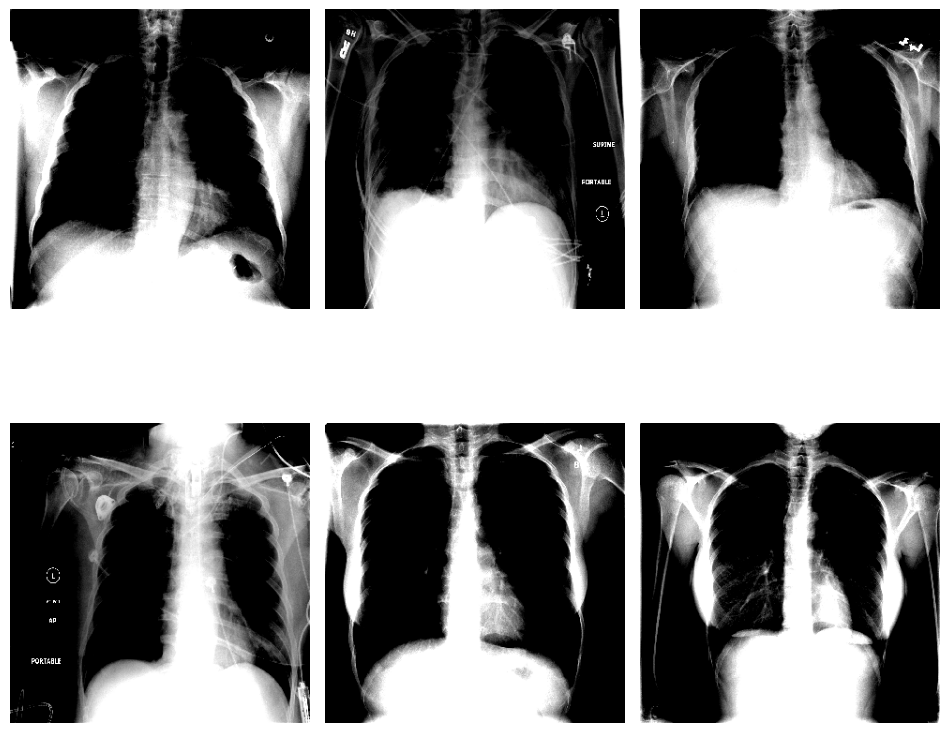

In [8]:
x, y = train_generator.__getitem__(0)
fig, axes = plt.subplots(2, 3, figsize=(9.6, 9.6))
for i, ax in enumerate(axes.flat):
    if i < len(x):
        ax.imshow(x[i])
    ax.axis('off')
plt.tight_layout();


### 3.3 Addressing Class Imbalance

Generally, when working with medical image datasets, there is always a limited amount of data examples to feed to the model (only ~1000 on average) due to various reasons related to strict regulations, costly expert annotation, and the rarity of diseases. This usually causes some conditions have roughly fewer examples than other, more frequent diseases. Let's plot the frequency of each of the pathologies in our dataset

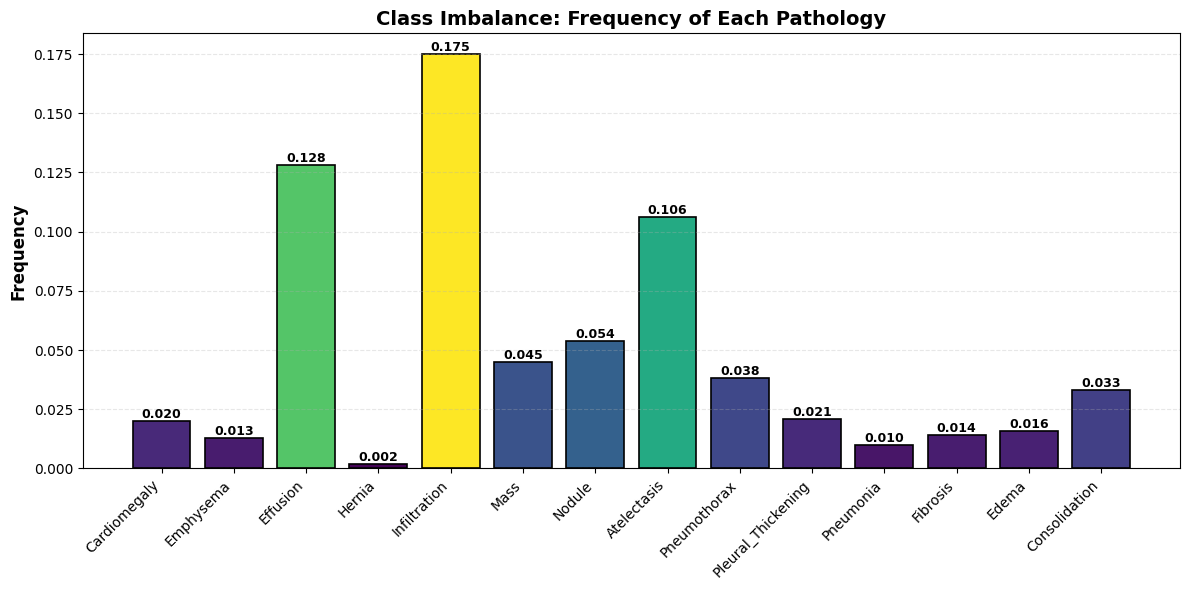

In [9]:
plt.figure(figsize=(12, 6))
frequencies = np.mean(train_generator.labels, axis=0)
colors = plt.cm.viridis(frequencies / frequencies.max())
bars = plt.bar(x=labels, height=frequencies, color=colors, edgecolor='black', linewidth=1.2)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Class Imbalance: Frequency of Each Pathology', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
for bar, freq in zip(bars, frequencies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{freq:.3f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


The plot depict the class imbalance between different pathologies, for example: 

* The [`Hernia`](https://www.nhs.uk/conditions/hernia/) pathology has only $0.002$ frequency of positive cases in the training set, while the [`Infiltration`](https://www.nhsfife.org/services/all-services/patient-advice/infiltration-and-extravasation/) pathology, which has the least amount of imbalance, has only $0.175$ to illustrate the minimum amount of examples of medical datasets.

The class imbalance would lead the algorithm to prioritize pathologies that contributes more to the loss function, and usually in medical images negative/healthy cases are the most present in datasets. This could be breakdown comparing the **Standard Loss Funciton** and **The Imbalance** in ***binary cross-entroy setup***: 



$$\mathcal{L} = - \frac{1}{N} \left( \sum_{i \in \text{pos}} \log(f(x_i)) + \sum_{j \in \text{neg}} \log(1 - f(x_j)) \right)$$

**The Imbalance Problem:**
If the dataset is highly imbalanced such that:
$$\sum \text{negative examples} \gg \sum \text{positive examples}$$




#### 3.3.1 Measure Class Frequencies between Positive/Negative Cases in our training set

In [10]:
# Calculate frequencies
N = train_generator.labels.shape[0]
freq_pos = np.sum(train_generator.labels, axis=0) / N
freq_neg = 1 - freq_pos

print("Pos Freqs: ", freq_pos)
print("Neg Freqs: ", freq_neg)

Pos Freqs:  [0.02  0.013 0.128 0.002 0.175 0.045 0.054 0.106 0.038 0.021 0.01  0.014
 0.016 0.033]
Neg Freqs:  [0.98  0.987 0.872 0.998 0.825 0.955 0.946 0.894 0.962 0.979 0.99  0.986
 0.984 0.967]


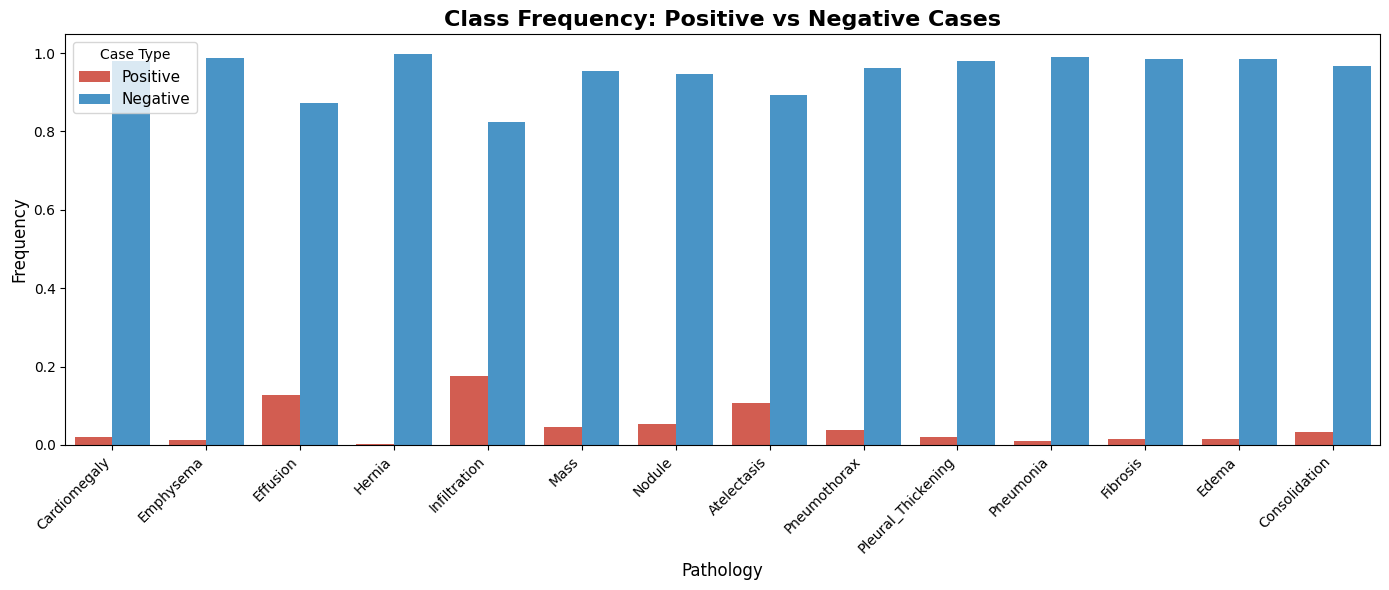

In [11]:
# Create dataframe for visualization
data = pd.DataFrame({"Class": labels, "Label": "Positive", "Value": freq_pos})
data = pd.concat([data, pd.DataFrame([{"Class": labels[l], "Label": "Negative", "Value": v} for l,v in enumerate(freq_neg)])], ignore_index=True)

# Create figure with better styling
plt.figure(figsize=(14, 6))
ax = sns.barplot(x="Class", y="Value", hue="Label", data=data, palette=["#e74c3c", "#3498db"])
plt.xticks(rotation=45, ha='right')
plt.title("Class Frequency: Positive vs Negative Cases", fontsize=16, fontweight='bold')
plt.ylabel("Frequency", fontsize=12)
plt.xlabel("Pathology", fontsize=12)
plt.legend(title="Case Type", fontsize=11)
plt.tight_layout()
plt.show()


* As depicted the ratio of positive cases to negative ones is significantly low for every pathology in the training set, this usually cause that negative cases provide so much feedback to the model that it stops trying to learn from the positive cases (diseases). 

#### 3.3.2 Apply Class Weighting to Achieve Equal Contribution  

* To achieve **equal contribtion** between the majority class(negative cases) and the minority class(positive cases), we use a technique called **Class Weighting**.

*  The goal is to mathematically ***boost*** the importance of the rare positive cases so that they have the same total influence on the model's learning as the thousands of negative cases.

* We want the total weight of all positive cases to equal the total of all negative cases. To do this, we multiply each class by a weight that is **inversely proportional** to its frequency. 
  - If a class is **rare**, we give it a **large weight**.
  - If a class is **common**, we give it a **small weight**.
To have this, we want 


1. Calculate Frequencies

 - For each pathology $i$, we first determine the frequency of positive and negative cases:

$$freq_{pos, i} = \frac{\text{count}(y_i = 1)}{N}$$
$$freq_{neg, i} = \frac{\text{count}(y_i = 0)}{N}$$

2. Assign Inverse Weights
 - We achieve balance by assigning a higher weight to the minority class and a lower weight to the majority class. We do this by "swapping" the frequencies:

* **Positive Weight ($w_{pos, i}$):** set to $freq_{neg, i}$
* **Negative Weight ($w_{neg, i}$):** set to $freq_{pos, i}$

3. Verify Equal Contribution
 - With this approach, the total contribution from each class becomes identical regardless of the number of samples:

    $$\text{Total Pos Contribution} = freq_{pos, i} \times w_{pos, i} = freq_{pos, i} \times freq_{neg, i}$$
    $$\text{Total Neg Contribution} = freq_{neg, i} \times w_{neg, i} = freq_{neg, i} \times freq_{pos, i}$$



Since $freq_{pos, i} \times freq_{neg, i} = freq_{neg, i} \times freq_{pos, i}$, the loss function now treats the rare disease cases with the same mathematical importance as the common healthy cases.

In [12]:
pos_weights = freq_neg
neg_weights = freq_pos

# Verify equal contribution
pos_contribution = freq_pos * pos_weights  
neg_contribution = freq_neg * neg_weights  

print("Positive contribution:", pos_contribution)
print("Negative contribution:", neg_contribution)
print("\nEqual contribution achieved:", np.allclose(pos_contribution, neg_contribution))


Positive contribution: [0.0196   0.012831 0.111616 0.001996 0.144375 0.042975 0.051084 0.094764
 0.036556 0.020559 0.0099   0.013804 0.015744 0.031911]
Negative contribution: [0.0196   0.012831 0.111616 0.001996 0.144375 0.042975 0.051084 0.094764
 0.036556 0.020559 0.0099   0.013804 0.015744 0.031911]

Equal contribution achieved: True


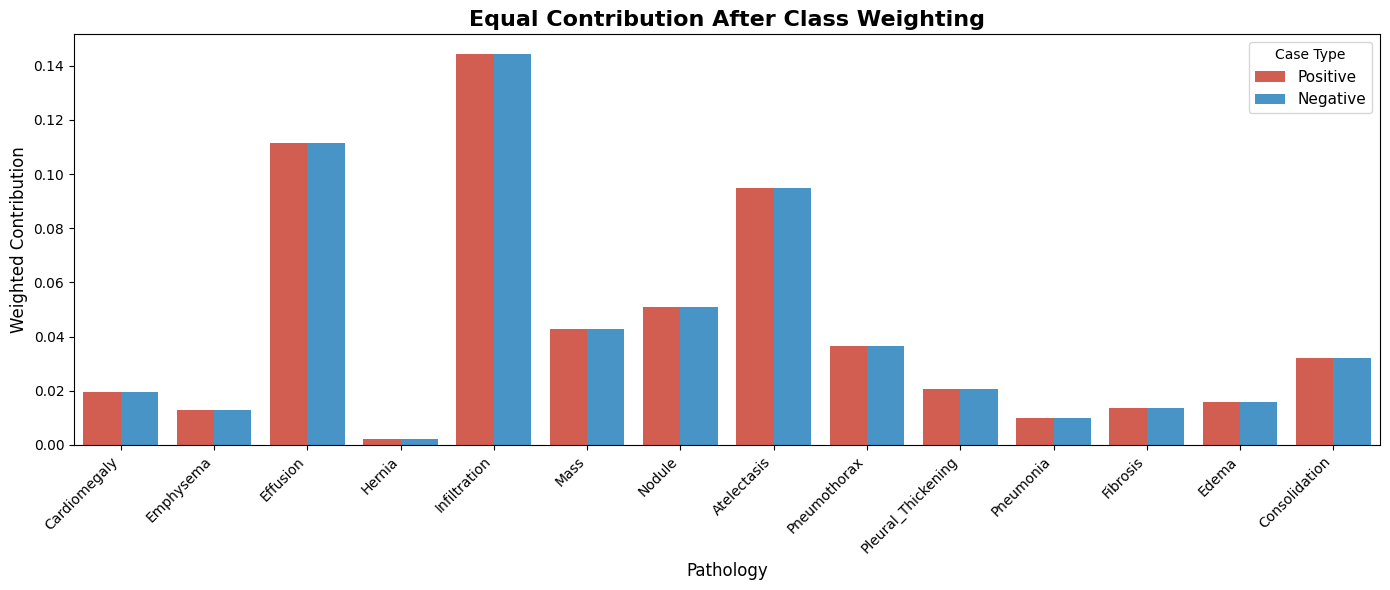

In [13]:
# Create dataframe for visualization
data = pd.DataFrame({"Class": labels, "Label": "Positive", "Value": pos_contribution})
data = pd.concat([data, pd.DataFrame([{"Class": labels[l], "Label": "Negative", "Value": v} for l,v in enumerate(neg_contribution)])], ignore_index=True)

# Create figure with better styling
plt.figure(figsize=(14, 6))
ax = sns.barplot(x="Class", y="Value", hue="Label", data=data, palette=["#e74c3c", "#3498db"])
plt.xticks(rotation=45, ha='right')
plt.title("Equal Contribution After Class Weighting", fontsize=16, fontweight='bold')
plt.ylabel("Weighted Contribution", fontsize=12)
plt.xlabel("Pathology", fontsize=12)
plt.legend(title="Case Type", fontsize=11)
plt.tight_layout()
plt.show()


#### 3.3.3 Get Weighted Loss

* The `weighted_loss` function is the engine that actually applies the **equal contribution** 

* We are dealing with **14 different pathologies** simultaneously (Multi-label classification), the total loss for a single batch of images is the sum of losses for each individual pathology. 
 - for each pathology $i$, we calculate the weighted loss, and then we sum them all up: 

    $$\text{Total Loss} = \sum_{i=1}^{14} \text{Loss}_i$$

* We will be using [`keras.mean`](https://www.tensorflow.org/api_docs/python/tf/keras/backend/mean) & [`keras.log`](https://www.tensorflow.org/api_docs/python/tf/keras/ops/log) functions allow the calculation gradients for backpropagation to be performed directly using `TensorFlow tensors` 
 - The [`Keras.mean`](https://www.tensorflow.org/api_docs/python/tf/keras/backend/mean) ensures that we get a single scalar value representing the average error for the specific batch of images, which the optimizer then uses to update the model weights. 

* The formula for **Binary Cross-Entrop Loss** involves taking the log of the model's prediction: $\log(f(x))$.
    $$\mathcal{L}_{cross-entropy}^{w}(x) = - (w_{p} y \log(f(x)) + w_{n}(1-y) \log( 1 - f(x) ) )$$

    - The Positive Term ($w_{p} y \log(f(x))$): Activates when the actual label is positive ($y=1$), when multiplying $\log(f(x))$ by $w_{p}$(which is a large numbe of rare diseases) the model learns that it's more painful to miss a rare disease.

    - The Negative Term ($w_{n}(1-y) \log( 1 - f(x) )$): Activates when the label is negative ($y=0$), the model learns that pain for each individual healthy case is small because we have so many of them. 

 - **The Error**: Mathematically,  $\log(0)$ is undefined (it tends toward negative infinity). 
 - **The Fix**: By adding a tiny value like $\epsilon = 10^{-7}$ to the prediction, we ensure the input to the log function is always slightly above $0$ to keep the math stable.

In [14]:
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    """
    Return weighted loss function for multi-label classification.
    
    Args:
      pos_weights (np.array): array of positive weights for each class, size (num_classes)
      neg_weights (np.array): array of negative weights for each class, size (num_classes)
      epsilon (float): small constant for numerical stability
    
    Returns:
      weighted_loss (function): weighted loss function
    """
    def weighted_loss(y_true, y_pred):
        """
        Return weighted loss value. 
        
        Args:
            y_true (Tensor): Tensor of true labels, size is (num_examples, num_classes)
            y_pred (Tensor): Tensor of predicted labels, size is (num_examples, num_classes)
        Returns:
            loss (float): overall scalar loss summed across all classes
        """
        loss = 0.0
        
        for i in range(len(pos_weights)):
            loss += -tf.reduce_mean(pos_weights[i] * y_true[:, i] * tf.math.log(y_pred[:, i] + epsilon) 
                                   + neg_weights[i] * (1 - y_true[:, i]) * tf.math.log(1 - y_pred[:, i] + epsilon))
        
        return loss
    
    return weighted_loss

# Test the weighted loss function
# Create sample data
y_true = tf.constant([[1.0, 0.0, 1.0], [0.0, 1.0, 0.0]])
y_pred = tf.constant([[0.8, 0.2, 0.7], [0.3, 0.9, 0.1]])

# Create sample weights
pos_weights = np.array([1.5, 2.0, 1.0])
neg_weights = np.array([0.5, 0.5, 1.0])

# Get the weighted loss function
weighted_loss_fn = get_weighted_loss(pos_weights, neg_weights)

# Calculate loss
loss = weighted_loss_fn(y_true, y_pred)

print(f"Loss: {loss.numpy()}")

Loss: 0.6486901044845581


In [15]:
# Test the weighted loss function
print("Testing Weighted Loss Function")
print("=" * 50)

# Create sample data (2 examples, 3 classes)
y_true = tf.constant([[1.0, 0.0, 1.0], 
                      [0.0, 1.0, 0.0]], dtype=tf.float32)

y_pred = tf.constant([[0.8, 0.2, 0.7], 
                      [0.3, 0.9, 0.1]], dtype=tf.float32)

# Create sample weights for 3 classes
pos_weights = np.array([1.5, 2.0, 1.0])
neg_weights = np.array([0.5, 0.5, 1.0])

print(f"\nTrue labels shape: {y_true.shape}")
print(f"Predicted labels shape: {y_pred.shape}")
print(f"\nTrue labels:\n{y_true.numpy()}")
print(f"\nPredicted labels:\n{y_pred.numpy()}")
print(f"\nPositive weights: {pos_weights}")
print(f"Negative weights: {neg_weights}")

# Get the weighted loss function
weighted_loss_fn = get_weighted_loss(pos_weights, neg_weights)

# Calculate loss
loss = weighted_loss_fn(y_true, y_pred)

print(f"\n{'=' * 50}")
print(f"Computed Loss: {loss.numpy():.6f}")
print(f"{'=' * 50}")

# Test with different predictions to show how loss changes
print("\n\nTesting with perfect predictions:")
y_pred_perfect = tf.constant([[1.0, 0.0, 1.0], 
                               [0.0, 1.0, 0.0]], dtype=tf.float32)
loss_perfect = weighted_loss_fn(y_true, y_pred_perfect)
print(f"Loss with perfect predictions: {loss_perfect.numpy():.6f}")

print("\n\nTesting with poor predictions:")
y_pred_poor = tf.constant([[0.2, 0.8, 0.3], 
                           [0.7, 0.1, 0.9]], dtype=tf.float32)
loss_poor = weighted_loss_fn(y_true, y_pred_poor)
print(f"Loss with poor predictions: {loss_poor.numpy():.6f}")

print("\n✓ Test completed successfully!")


Testing Weighted Loss Function

True labels shape: (2, 3)
Predicted labels shape: (2, 3)

True labels:
[[1. 0. 1.]
 [0. 1. 0.]]

Predicted labels:
[[0.8 0.2 0.7]
 [0.3 0.9 0.1]]

Positive weights: [1.5 2.  1. ]
Negative weights: [0.5 0.5 1. ]

Computed Loss: 0.648690


Testing with perfect predictions:
Loss with perfect predictions: -0.000000


Testing with poor predictions:
Loss with poor predictions: 5.966293

✓ Test completed successfully!


## 4. Training the Model with DenseNet 121 

### 4.1 [`DenseNet121`](https://www.kaggle.com/datasets/pytorch/densenet121)

* In medical imaging, <u>we rarely train a model from scratch</u> because we lack the millions of images required to learn basic visual patterns. Instead, we use **Transfer Learning** with a high-performing architecture like [`DenseNet121`](https://www.kaggle.com/pytorch/densenet121)

* [`DenseNet121`](https://www.kaggle.com/pytorch/densenet121) (**Densely Connected Convolutional Networks**) is particulary effective for X-ray. In a [DenseNet121](https://www.kaggle.com/pytorch/densenet121), each layer receives feature maps from all preceding layers. This helps the model preserve fine-grained details (e.g., like a small lung nodule or subtle pleural thickening) that might otherwise be lost in deeper layers of a standard network. 

* When we load the **pre-trained** [`DenseNet121`](https://www.kaggle.com/pytorch/densenet121), we remove its original top layer designed for 1,000 general objects and add our own specialized "head", the layers to be added:

    1. **[`GlobalAveragePooling2D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D)**:Takes the average value of each feature map. This reduces the data's dimensionality while keeping the most important infromation about the presence of features across the entire image. 

    2. **[`Sigmoid`](https://keras.io/api/layers/activations/)**: We add a final `Dense` (fully connected) layer with **14 units**. Each unit corresponds to one of our target pathologies (e.g., Pneumonia, Edema). We use [`Sigmoid`](https://keras.io/api/layers/activations/) for "Multi-label" (a patient can have both an Effusion and Cardiomegaly at the same time). It forces each of the 14 outputs to be a probability between $0$ and $1$ independently.

    <img src="/home/mukhtarfeth32/AI for Medicine Projects/AI for Medical Diagnosis/Chest X-Ray Medical Diagnosis with DL (1)/images/densenet121.png">


In [16]:
# Create base pre-trained model
base_model = DenseNet121(weights='models/nih/densenet.hdf5', include_top=False)
x = GlobalAveragePooling2D()(base_model.output)
predictions = Dense(len(labels), activation="sigmoid")(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=get_weighted_loss(pos_weights, neg_weights),
    metrics=['binary_accuracy']
)


### 4.2 Model Training

* In [`keras.model.fit`](https://keras.io/api/models/model_training_apis/) is the command that starts the learning process. The model takes the images from `train_generator`, makes a prediction, compares it to the real label using your **Weighted Loss function**, and updates its internal weights to perform better next time. 
 - [`Keras Callbacks`](https://keras.io/api/callbacks/): Are essential **autopilot** tools for training deep learning models, these callbacks ensure the model stops at the perfect moment and doesn't get "stuck" during learning. Each callback serves a specific purpose to optimize the training process: 

   - `ModelCheckpoint`: Saves the model's weights to a file (`best_model.h5`) whenever the validation loss improves. 
   
   - `ReduceLROnPlateau`: Monitors the validation loss. If the loss stops improving for a certain number of epochs (`patience=2`), it cuts the learning rate by half (`factor=0.5`).
   
   - `EarlyStopping`: Stops the training entirely if the validation loss doesn't improve for 5 consecutive epochs to prevents $Overfitting$

 - `steps_per_epoch=100`: This tells the model to <u>pull 100 batches of images from the generator per epoch</u>, because we are using a subset, we don't need to look at every single image to see the loss start to drop. 

 - `epochs=20`: An epoch is one full pass through the training data. Here, **the model repeats the learning process 3 times.**

 - `validation_data`: While the model learns from the training set, it simultaneously checks its performance on the `valid_generator` that contains data it hasn't seen for training to ensure it isn't just memorizing images (overfitting), this practice is called **Cross Validation**

* The primary signal that the model is actually learning is the **Loss Curve**, in medical imaging, `Loss` **represents the error between the model's diagnosis and the radiologist's ground truth.**

* Since the X-Ray subset is relatively small we ensure that <u>the loss is decreasing</u>


In [17]:
# Training callbacks
callbacks = [
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

# Full training
print("Starting training...")
print("=" * 60)
history = model.fit(
    train_generator, 
    validation_data=valid_generator,
    steps_per_epoch=100,  # Full steps
    validation_steps=25,   # Full steps
    epochs=20,             # Full epochs
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("✓ Training completed successfully!")
print("=" * 60)


Starting training...
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - binary_accuracy: 0.6752 - loss: 0.8020
Epoch 1: val_loss improved from None to 2.85340, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 979s 9s/step - binary_accuracy: 0.6873 - loss: 0.6377 - val_binary_accuracy: 0.7125 - val_loss: 2.8534 - learning_rate: 0.0010
Epoch 2/20
 25/100 ━━━━━━━━━━━━━━━━━━━━ 10:18 8s/step - binary_accuracy: 0.6907 - loss: 0.6205

/home/mukhtarfeth32/AI for Medicine Projects/AI for Medical Diagnosis/Chest X-Ray Medical Diagnosis with DL (1)/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 2.85340
100/100 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - binary_accuracy: 0.6889 - loss: 0.5904 - val_binary_accuracy: 0.6836 - val_loss: 2.8695 - learning_rate: 0.0010
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - binary_accuracy: 0.6876 - loss: 0.5999
Epoch 3: val_loss improved from 2.85340 to 2.02984, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 868s 9s/step - binary_accuracy: 0.6881 - loss: 0.5849 - val_binary_accuracy: 0.7004 - val_loss: 2.0298 - learning_rate: 0.0010
Epoch 4/20
 25/100 ━━━━━━━━━━━━━━━━━━━━ 10:05 8s/step - binary_accuracy: 0.6895 - loss: 0.5588
Epoch 4: val_loss improved from 2.02984 to 0.99863, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - binary_accuracy: 0.6886 - loss: 0.6053 - val_binary_accuracy: 0.7132 - val_loss: 0.9986 - learning_rate: 0.0010
Epoch 5/20
100/100 ━━━━

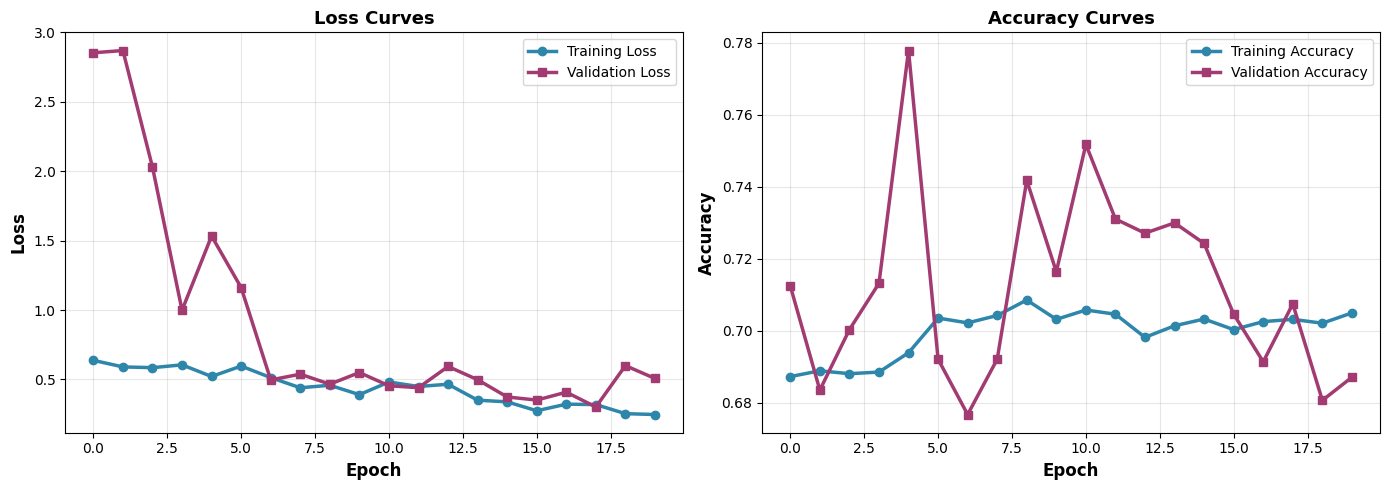


TRAINING SUMMARY
Final Training Loss:       0.2474
Final Validation Loss:     0.5071
Final Training Accuracy:   0.7050
Final Validation Accuracy: 0.6871
Best Validation Loss:      0.3017
Number of Epochs:          20


In [18]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(history.history['loss'], linewidth=2.5, color='#2E86AB', marker='o', label='Training Loss')
axes[0].plot(history.history['val_loss'], linewidth=2.5, color='#A23B72', marker='s', label='Validation Loss')
axes[0].set_ylabel("Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12, fontweight='bold')
axes[0].set_title("Loss Curves", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history.history['binary_accuracy'], linewidth=2.5, color='#2E86AB', marker='o', label='Training Accuracy')
axes[1].plot(history.history['val_binary_accuracy'], linewidth=2.5, color='#A23B72', marker='s', label='Validation Accuracy')
axes[1].set_ylabel("Accuracy", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12, fontweight='bold')
axes[1].set_title("Accuracy Curves", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Final Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy:   {history.history['binary_accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_binary_accuracy'][-1]:.4f}")
print(f"Best Validation Loss:      {min(history.history['val_loss']):.4f}")
print(f"Number of Epochs:          {len(history.history['loss'])}")
print("=" * 60)


## 5. Model Evaluation

### 5.1. Evaluate The Model On The Test Set 

* After the model has finished learning (training), we need to see how it performs on completely new data that <u>it has never seen before</u>: the **`Test Set.`**

* The process of using a trained model to make predictions on new data is called the **`inference`** phase of the project.
, during which the model simply looks at the X-ray and outputs the probability (a number between 0 and 1) for each of the 14 pathologies.

INFERENCE PHASE: Testing on Unseen Data
53/53 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - binary_accuracy: 0.6466 - loss: 2.2375

✓ Test Loss: 2.2375
✓ Compile_metrics: 0.6466 (64.66%)
53/53 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step

✓ Predictions shape: (420, 14)
  - 420 images
  - 14 pathologies (probabilities between 0 and 1)

Sample Predictions (First 3 Images):

Image 1:
  Cardiomegaly        : 0.0936 (9.36%)
  Emphysema           : 0.0183 (1.83%)
  Effusion            : 0.2665 (26.65%)
  Hernia              : 0.5587 (55.87%)
  Infiltration        : 0.7317 (73.17%)
  Mass                : 0.1688 (16.88%)
  Nodule              : 0.6702 (67.02%)
  Atelectasis         : 0.4457 (44.57%)
  Pneumothorax        : 0.2610 (26.10%)
  Pleural_Thickening  : 0.6671 (66.71%)
  Pneumonia           : 0.1989 (19.89%)
  Fibrosis            : 0.2874 (28.74%)
  Edema               : 0.3970 (39.70%)
  Consolidation       : 0.3373 (33.73%)

Image 2:
  Cardiomegaly        : 0.0133 (1.33%)
  Emphysema           : 0.0047 (

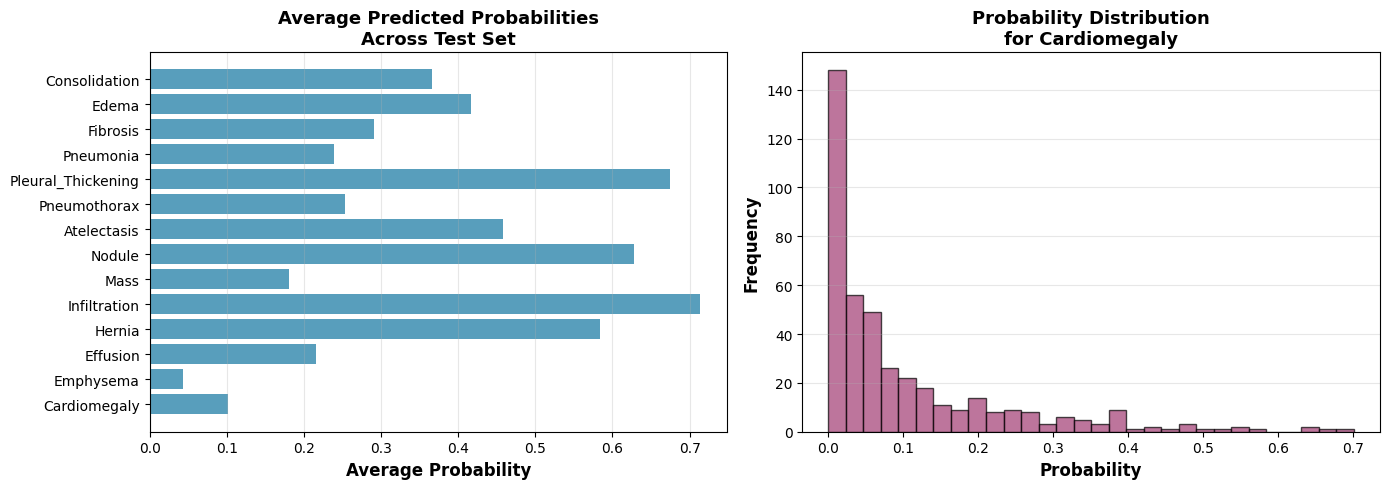

In [20]:
# Inference Phase: Evaluate on Test Set
print("=" * 60)
print("INFERENCE PHASE: Testing on Unseen Data")
print("=" * 60)

# Evaluate model performance (flexible unpacking)
results = model.evaluate(test_generator, steps=len(test_generator))

# Handle different numbers of returned values
test_loss = results[0]
print(f"\n✓ Test Loss: {test_loss:.4f}")

# Print all metrics dynamically
for i, metric_name in enumerate(model.metrics_names[1:], 1):
    print(f"✓ {metric_name.capitalize()}: {results[i]:.4f} ({results[i]*100:.2f}%)")

# Make predictions on test set (inference)
predictions = model.predict(test_generator, steps=len(test_generator))
predictions = np.array(predictions)

print(f"\n✓ Predictions shape: {predictions.shape}")
print(f"  - {predictions.shape[0]} images")
print(f"  - {predictions.shape[1]} pathologies (probabilities between 0 and 1)")

# Display sample predictions
print("\n" + "=" * 60)
print("Sample Predictions (First 3 Images):")
print("=" * 60)
for i in range(min(3, len(predictions))):
    print(f"\nImage {i+1}:")
    for j, label in enumerate(labels):
        prob = predictions[i, j]
        print(f"  {label:20s}: {prob:.4f} ({prob*100:.2f}%)")

# Visualize prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average probabilities per pathology
avg_probs = predictions.mean(axis=0)
axes[0].barh(labels, avg_probs, color='#2E86AB', alpha=0.8)
axes[0].set_xlabel('Average Probability', fontsize=12, fontweight='bold')
axes[0].set_title('Average Predicted Probabilities\nAcross Test Set', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Prediction distribution for first pathology
axes[1].hist(predictions[:, 0], bins=30, color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'Probability Distribution\nfor {labels[0]}', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 5.2 Evaluating The Model ROC Curve and AUROC

* The **[ROC (Receiver Operating Characteristic) Curve](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)** and **AUC (Area Under the Curve)** are the <u>gold standard</u> for evaluating diagnostic models in medicine because the curve tells how well the model balance **Sensitivity**(finding the sick people) and **Specificity** (not worrying the healthy people).

* The ROC curve is a plot of the **True Positive Rate** ($Sensitivity$) against the **False Positive Rate** ($1 - Specificity$) at various threshold settings. 
  
  - **True Positive Rate**: Out of all people who actually have the disease, how many did the model <u>correctly identify</u>?

  - **False Positive Rate**: Out of all healthy people, how many did the model <u>mistakenly say were sick</u>?

* The shape of the curve tells you the quality of the model **a perfect model** would rushes the **top-left corner**, therefore, we want the curves for each of the 14 pathologies to bow as far toward the top-left as possible.

* The **AUROC** is a single number between $0$ and $1$ that summarizes the entire ROC curve: 
   - **AUC = 0.7**: Generally considered ***acceptable*** in clinical settings.
   - **AUC > 0.8 or 0.9**: Considered ***excellent*** or ***state-of-the-art***

* The **AUC** is <u>imbalance-blind</u>; it rewards the model for being able to distinguish between a sick person and a healthy person, regardless of how many healthy people are in the dataset.

* We would use [`sklearn`](http://scikit-learn.org/) library is the engine for the math, its static plots can be limiting when you want to explore how different decision thresholds impact patient care in a clinical setting. There are 2 main functions to be use:

  - [`roc_curve`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html): Calculates the points needed to plot the line. 
  - [`roc_auc_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html): Calculates the final area (the $0.0$ to $1.0$ score)


In [15]:
# Load the trained model
from tensorflow.keras.models import load_model
import tensorflow as tf

# Define the custom weighted loss function (required for loading the model)
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    def weighted_loss(y_true, y_pred):
        loss = 0.0
        for i in range(len(pos_weights)):
            loss += -tf.reduce_mean(pos_weights[i] * y_true[:, i] * tf.math.log(y_pred[:, i] + epsilon) 
                                   + neg_weights[i] * (1 - y_true[:, i]) * tf.math.log(1 - y_pred[:, i] + epsilon))
        return loss
    return weighted_loss

# Calculate weights (assuming you have train_df and labels defined)
freq_pos = train_df[labels].mean(axis=0).values
freq_neg = 1 - freq_pos
pos_weights = freq_neg
neg_weights = freq_pos
weighted_loss = get_weighted_loss(pos_weights, neg_weights)

# Load the model with custom objects
model = load_model('best_model.keras', custom_objects={'weighted_loss': weighted_loss})

# Recreate test_generator (assuming test_df, labels, IMAGE_DIR are defined)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sample training data to compute normalization statistics
raw_train_generator = ImageDataGenerator().flow_from_dataframe(
    dataframe=train_df, 
    directory=IMAGE_DIR, 
    x_col="Image", 
    y_col=labels, 
    class_mode="raw", 
    batch_size=100, 
    shuffle=True, 
    target_size=(320, 320))

# Get sample and compute statistics
batch = raw_train_generator.__next__()
data_sample = batch[0]

# Create generator with featurewise normalization
image_generator = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True)

# Fit to training sample
image_generator.fit(data_sample)

# Create test generator
test_generator = image_generator.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col="Image",
    y_col=labels,
    class_mode="raw",
    batch_size=8,
    shuffle=False,
    seed=1,
    target_size=(320, 320))

# Make predictions
predictions = model.predict(test_generator)

# Evaluate the model
test_loss, test_auc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")

Found 1000 validated image filenames.
Found 420 validated image filenames.
53/53 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - binary_accuracy: 0.6473 - loss: 2.7938
Test Loss: 2.7938, Test AUC: 0.6473


Generating predictions on test set...
53/53 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step

Predictions shape: (420, 14)
True labels shape: (420, 14)

Generating ROC curves for all classes...


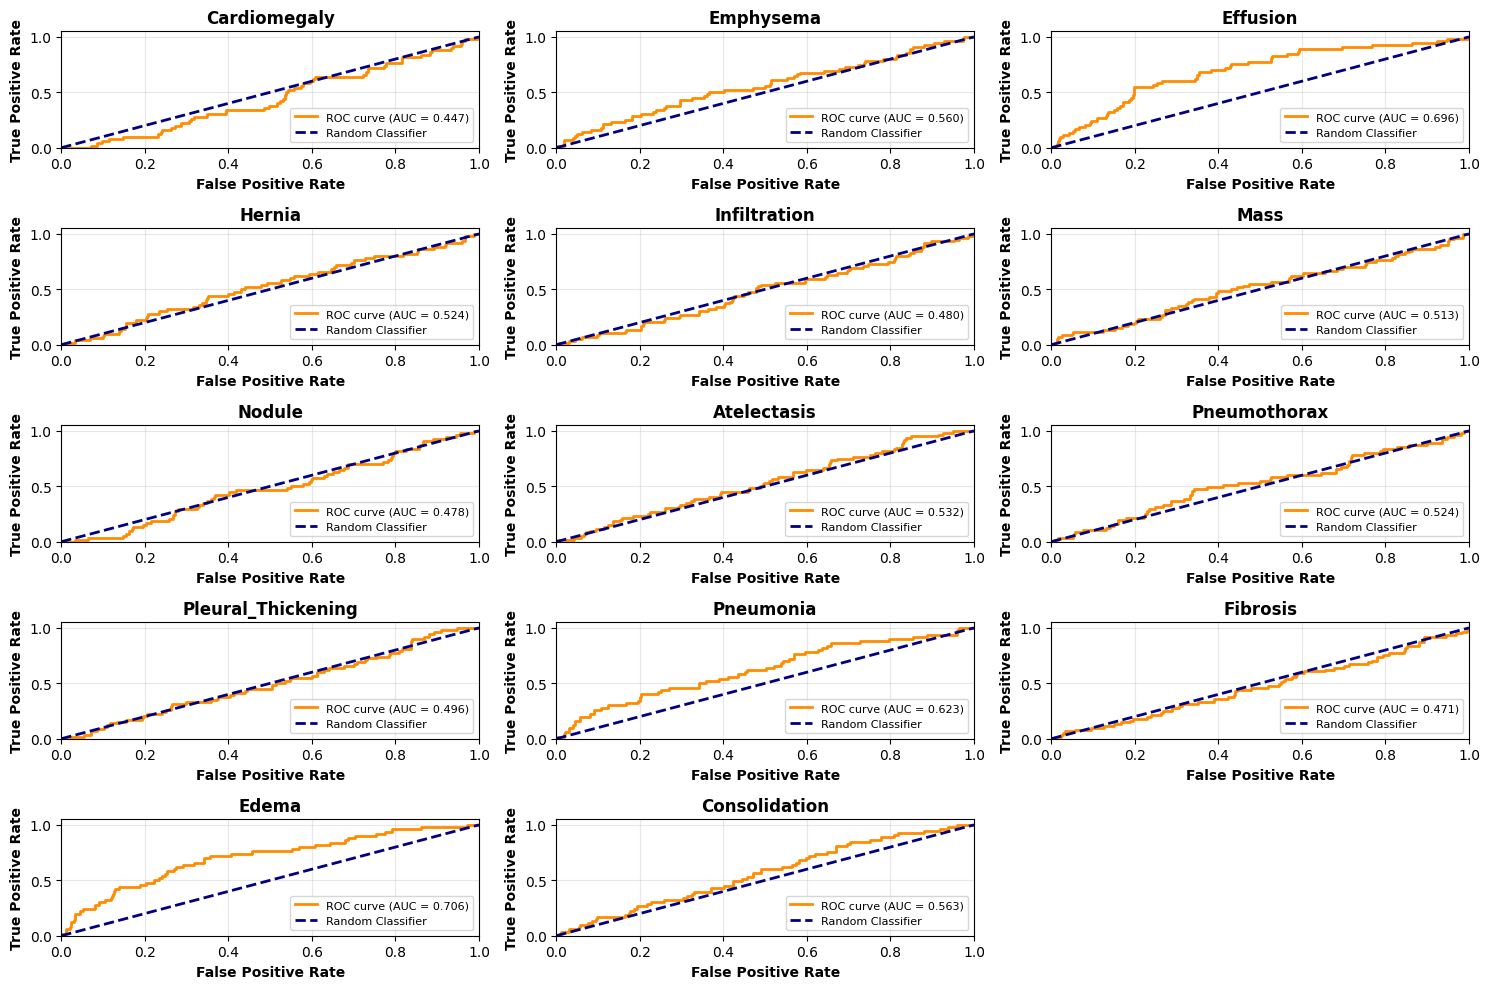

ROC AUC SCORES SUMMARY
Class                           AUC Score
----------------------------------------------------------------------
Cardiomegaly                       0.4471
Emphysema                          0.5595
Effusion                           0.6962
Hernia                             0.5236
Infiltration                       0.4797
Mass                               0.5126
Nodule                             0.4782
Atelectasis                        0.5318
Pneumothorax                       0.5240
Pleural_Thickening                 0.4961
Pneumonia                          0.6226
Fibrosis                           0.4706
Edema                              0.7065
Consolidation                      0.5626
----------------------------------------------------------------------
Mean AUC                           0.5437

Generating mean ROC curve...


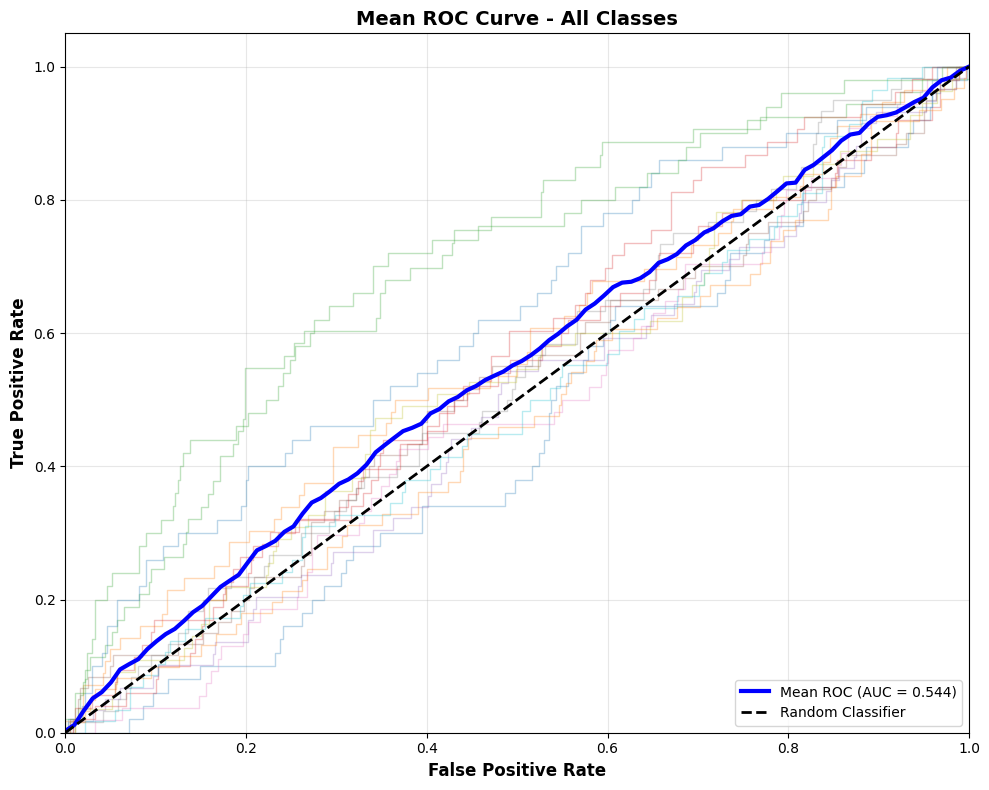


Mean AUC across all classes: 0.5437


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_curves(y_true, y_pred, labels, figsize=(15, 10)):
    """
    Generate ROC curves and calculate AUROC for multi-label classification.
    
    Args:
        y_true: True labels (numpy array of shape [n_samples, n_classes])
        y_pred: Predicted probabilities (numpy array of shape [n_samples, n_classes])
        labels: List of class names
        figsize: Figure size for the plot
    
    Returns:
        roc_auc_dict: Dictionary containing AUROC scores for each class
    """
    
    # Dictionary to store ROC AUC scores
    roc_auc_dict = {}
    
    # Create figure with subplots
    n_classes = len(labels)
    n_cols = 3
    n_rows = (n_classes + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    # Generate ROC curve for each class
    for i, label in enumerate(labels):
        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_true[:, i], y_pred[:, i])
        
        # Calculate AUC
        roc_auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        roc_auc_dict[label] = roc_auc
        
        # Plot ROC curve
        axes[i].plot(fpr, tpr, color='darkorange', lw=2, 
                     label=f'ROC curve (AUC = {roc_auc:.3f})')
        axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                     label='Random Classifier')
        axes[i].set_xlim([0.0, 1.0])
        axes[i].set_ylim([0.0, 1.05])
        axes[i].set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
        axes[i].set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
        axes[i].set_title(f'{label}', fontsize=12, fontweight='bold')
        axes[i].legend(loc="lower right", fontsize=8)
        axes[i].grid(alpha=0.3)
    
    # Hide extra subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=" * 70)
    print("ROC AUC SCORES SUMMARY")
    print("=" * 70)
    print(f"{'Class':<25} {'AUC Score':>15}")
    print("-" * 70)
    
    for label, score in roc_auc_dict.items():
        print(f"{label:<25} {score:>15.4f}")
    
    print("-" * 70)
    mean_auc = np.mean(list(roc_auc_dict.values()))
    print(f"{'Mean AUC':<25} {mean_auc:>15.4f}")
    print("=" * 70)
    
    return roc_auc_dict


def plot_mean_roc_curve(y_true, y_pred, labels, figsize=(10, 8)):
    """
    Plot the mean ROC curve across all classes.
    
    Args:
        y_true: True labels (numpy array)
        y_pred: Predicted probabilities (numpy array)
        labels: List of class names
        figsize: Figure size for the plot
    """
    
    plt.figure(figsize=figsize)
    
    # Calculate ROC curve and AUC for each class
    all_fpr = []
    all_tpr = []
    all_auc = []
    
    for i in range(len(labels)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        all_fpr.append(fpr)
        all_tpr.append(tpr)
        all_auc.append(roc_auc)
        
        # Plot individual ROC curves with transparency
        plt.plot(fpr, tpr, alpha=0.3, lw=1)
    
    # Calculate mean AUC
    mean_auc = np.mean(all_auc)
    
    # Plot mean ROC curve
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    
    for fpr, tpr in zip(all_fpr, all_tpr):
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
    
    mean_tpr /= len(labels)
    
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=3, 
             label=f'Mean ROC (AUC = {mean_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('Mean ROC Curve - All Classes', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nMean AUC across all classes: {mean_auc:.4f}")


# Example usage:
# Make predictions on test set
print("Generating predictions on test set...")
y_pred = model.predict(test_generator, steps=len(test_generator))
y_true = test_generator.labels  # Assuming your generator has a labels attribute

# If your generator doesn't have labels attribute, extract them manually:
# y_true = []
# for i in range(len(test_generator)):
#     _, labels_batch = test_generator[i]
#     y_true.append(labels_batch)
# y_true = np.vstack(y_true)

# Convert to numpy arrays if needed
y_pred = np.array(y_pred)
y_true = np.array(y_true)

print(f"\nPredictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

# Plot ROC curves for all classes
print("\nGenerating ROC curves for all classes...")
roc_auc_scores = plot_roc_curves(y_true, y_pred, labels)

# Plot mean ROC curve
print("\nGenerating mean ROC curve...")
plot_mean_roc_curve(y_true, y_pred, labels)


<a name='5-2'></a>
### 5.2 Visualizing Learning with GradCAM 

* This section addresses the **"Black Box"** problem of Arificial Intelligence in medicine. While a `DenseNet` is highly accurate, it doesn't <u>explain why it thinks a patient has a specific condition</u>. This lack of transparency is a major barrier to clinical adoption. **[Grad-CAM](https://pyimagesearch.com/2020/03/09/grad-cam-visualize-class-activation-maps-with-keras-tensorflow-and-deep-learning/)(Gradient-weighted Class Activation Mapping)** is the solution used to bridge this gap. 

* Deep Learning models have millions of parameters, therefore, we need a way to visualize the model's "attention."

* **[Grad-CAM](https://pyimagesearch.com/2020/03/09/grad-cam-visualize-class-activation-maps-with-keras-tensorflow-and-deep-learning/)** works by looking at the last convoluional layer of our DenseNet121, since the final convolutional layer sees complex "pathological" features (like the shape of an 🫀enlarged heart). The [`Grad-CAM`](https://pyimagesearch.com/2020/03/09/grad-cam-visualize-class-activation-maps-with-keras-tensorflow-and-deep-learning/) technique calculates the gradient of the predicted score (e.g., the probability of "Cardiomegaly") with respect to the feature maps of that last layer. 

* [`Grad-CAM`](https://pyimagesearch.com/2020/03/09/grad-cam-visualize-class-activation-maps-with-keras-tensorflow-and-deep-learning/) essentially asks: "Which parts of this feature map, if changed slightly, would have the biggest impact on the final score?" Those high-impact areas are then colored (usually 🟥red for high importance, 🟦blue for low) and overlaid onto the original X-ray. 

* We are using [`Grad-CAM`] for 2 primary reasons: 

    1. **Model Debugging (The "Clever Hans" Effect):** If the model predicts "Effusion" but the Grad-CAM heatmap is glowing over the patient's shoulder instead of pleural space, we know that the model learned a "shortcut" and cannot be trusted, even if its AUC score is high.

    2. **Expert Augmentation:** When a doctor uses our `live classifier`, the heatmap acts as a "second set of eyes." It doesn't just say "Positive for Mass"; it circles the area it thinks is a mass, allowing the radiologist to quickly confirm or dismiss the finding. 

* The [`Grad-CAM`] is not a "full explanation." it shows **localization** (where), but not **logic** (how).
    
    - It shows that the model looked at the heart to predict Cardiomegaly. 

    - It doesn't explain that it measured the cadiothoracic ratio or analyzed the cardiac silhouette. 

First we will load the small training set and setup to look at the 4 classes with the highest performing AUC measures.

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

df = pd.read_csv("data/nih/train-small.csv")
IMAGE_DIR = "data/nih/images-small/"

# Compute AUC scores for each label (assuming y_true and y_pred are defined from previous cell)
auc_rocs = [roc_auc_score(y_true[:, i], y_pred[:, i]) for i in range(len(labels))]

# only show the labels with top 4 AUC
labels_to_show = np.take(labels, np.argsort(auc_rocs)[::-1])[:4]

Now let's look at a few specific images.

In [ ]:
util.compute_gradcam(model, '00008270_015.png', IMAGE_DIR, df, labels, labels_to_show)

In [ ]:
util.compute_gradcam(model, '00011355_002.png', IMAGE_DIR, df, labels, labels_to_show)

In [ ]:
util.compute_gradcam(model, '00029855_001.png', IMAGE_DIR, df, labels, labels_to_show)

In [ ]:
util.compute_gradcam(model, '00005410_000.png', IMAGE_DIR, df, labels, labels_to_show)